In [38]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow import keras
from sklearn.pipeline import Pipeline

%reload_ext autoreload
%autoreload 2
import utils
import transformers as tx

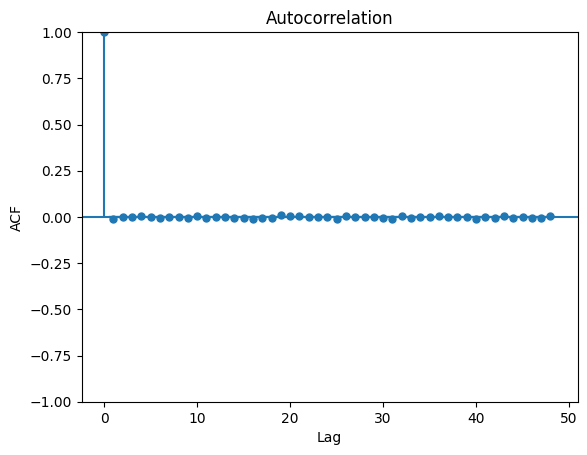

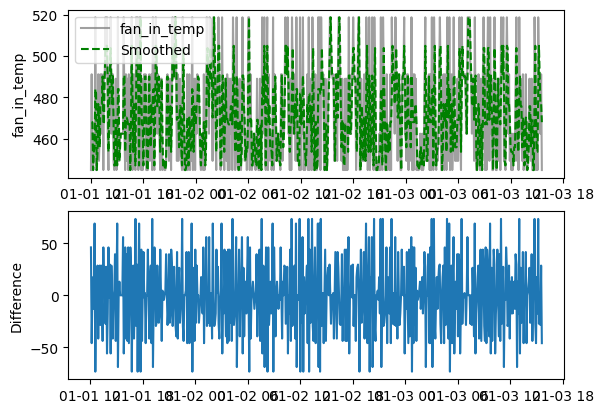

In [82]:
# set the width and number of columns displayed
pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 12)
################################################
metadata = ["unit","cycles","RUL"]
df = pd.read_csv("train_FD004.csv")
diffcols = ['altitude_kft', 'mach', 'temperature_F', 'fan_in_temp', 'lpc_out_temp', 'hpc_out_temp', 
            'lpt_out_temp', 'fan_in_press', 'bypass_press', 'hpc_out_press', 'fan_speed', 'core_speed', 
            'epr', 'hpc_stat_press', 'flow_press_ratio', 'corr_fan_speed', 'corr_core_speed', 
            'bypass_ratio', 'burner_fuel_ratio', 'bleed_enthalpy', 'dmd_fan_speed', 'dmd_corr_fan_speed', 
            'hpt_bleed', 'lpt_bleed']
pipe = Pipeline([
    ("rename", tx.OsRenamer()),
    ("datetime", tx.DateTimeIndexer(step=pd.Timedelta("5m"))),
    ("diff", tx.DiffCalc(cols=diffcols, groupkey="unit"))
    # ("filt", tx.MedianFilter(filtcols=[], refcol="RUL",
    #                          groupkey="unit", kmax=10, 
    #                          kstep=2, verbose=1)),
    # ("scale", tx.CustomScaler(x_cols=[], scaler=StandardScaler()))
])
df = pipe.fit_transform(df)
# print(df.corr()["RUL"].sort_values(key=abs, ascending=False))
# utils.graph_ts(df[df["unit"]==1], ["temperature_F","fan_in_temp","fan_speed","RUL"])
col = "fan_in_temp"
utils.acf_plot(df, col)
utils.plot_diff_smooth(df[df["unit"]<=2], col, 2)